# 数据预处理

In [1]:
with open('shakespeare.txt', 'r', encoding='utf-8') as f:
    text = f.read()

print(f"文本长度: {len(text)}")
print(f"文本前100个字符:\n{text[:100]}")
# 获取所有字符的集合，并排好序
chars = sorted(list(set(text)))

# 生成char到int的映射词典
char2idx = {ch: idx for idx, ch in enumerate(chars)}
# 生成int到char的映射词典
idx2char = {idx: ch for idx, ch in enumerate(chars)}

print(f"Total chars: {len(chars)}")
print(f"Example char2idx: {list(char2idx.items())[:10]}")
print(f"Example idx2char: {list(idx2char.items())[:10]}")


文本长度: 1115394
文本前100个字符:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You
Total chars: 65
Example char2idx: [('\n', 0), (' ', 1), ('!', 2), ('$', 3), ('&', 4), ("'", 5), (',', 6), ('-', 7), ('.', 8), ('3', 9)]
Example idx2char: [(0, '\n'), (1, ' '), (2, '!'), (3, '$'), (4, '&'), (5, "'"), (6, ','), (7, '-'), (8, '.'), (9, '3')]


In [2]:
# 将文本转换为数字序列
import numpy as np

# 使用列表推导式将每个字符映射为对应的整数id
# 遍历整个文本字符串，依次查找每个字符在char2idx映射字典中的索引
# 例如，如果text的第一个字符是'H'，char2idx['H']可能等于10，则列表第一个元素为10
text_as_int = np.array([char2idx[c] for c in text])  # 把全部文本都转为id，生成numpy数组，便于后续模型处理

# 打印文本被转为id后的总长度（等于原始字符数）
print(len(text_as_int))

# 查看前20个数字id，便于检查数值化效果
text_as_int[:20]

1115394


array([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43,
       44, 53, 56])

In [3]:
# 定义序列长度和批次大小
import torch
from torch.utils.data import Dataset, DataLoader

# 设置每个输入序列的长度（字符数量）
seq_length = 100  # 每个样本的序列长度，RNN每次看到100个字符进行学习
# 设置每个批次中的样本的数量
batch_size = 64   # 每个批次的样本数量，提升训练效率

# 创建自定义数据集类，继承自torch.utils.data.Dataset
class ShakespeareDataset(Dataset):
    def __init__(self, text_as_int, seq_length):
        """
        参数:
        text_as_int: 整型数组，表示文本的每个字符的索引
        seq_length: 每个训练样本的长度
        """
        self.text_as_int = text_as_int  # 原始文本的索引形式
        self.seq_length = seq_length
        self.sub_len = seq_length + 1   # 每个样本包括seq_length个输入字符+1个目标字符（预测下一个）

    def __len__(self):
        """
        返回数据集能够切分出来的样本个数
        由于每个样本长度为seq_length+1，所以样本数为text总长除以这个长度
        """
        # +1是因为需要用前面的字符预测下一个字符
        return len(self.text_as_int) // self.sub_len

    def __getitem__(self, idx):
        """
        返回单个样本，类型为torch.LongTensor
        样本格式： [c1, c2, ..., c_n, c_{n+1}]
        前n个是输入，第n+1个为目标
        """
        # 计算起止下标，切片获取数据，转换为Long张量
        start = idx * self.sub_len
        end = (idx + 1) * self.sub_len
        return torch.tensor(self.text_as_int[start:end], dtype=torch.long)

# 定义collate函数，用于DataLoader批量组装数据
def collate_fct(batch):
    """
    批次组装函数，将列表中的样本堆叠成一个batch，并切分输入和目标
    输入: batch - list，每个元素为长度为seq_length+1的LongTensor
    输出: 
        input_batch: 输入序列 [batch_size, seq_length]
        target_batch: 目标序列 [batch_size, seq_length]
    """
    # 将batch中的每个样本沿着新维度堆叠成一个二维张量 [batch_size, seq_length+1]
    batch = torch.stack(batch)
    # 输入序列取前seq_length个字符
    input_batch = batch[:, :-1]
    # 目标序列为紧跟在输入序列之后的字符（用于下一个字符预测）
    target_batch = batch[:, 1:]
    return input_batch, target_batch

# 创建Shakespeare数据集的Dataset实例
shakespeare_dataset = ShakespeareDataset(text_as_int, seq_length)

# 用DataLoader批量加载数据
# shuffle=True: 每次epoch都打乱数据，提高泛化能力
# drop_last=True: 若末尾不足一个批次则丢弃，保证每个batch大小一致
# collate_fn指定自定义的拼接处理方式
dataloader = DataLoader(
    shakespeare_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=True, 
    collate_fn=collate_fct
)

# 示例：从dataloader中取一个批次，并打印输入与目标
for input_batch, target_batch in dataloader:
    print(f"输入批次形状: {input_batch.shape}")     # [batch_size, seq_length]
    print(f"目标批次形状: {target_batch.shape}")     # [batch_size, seq_length]
    
    # 打印第一个batch中的输入和目标Tensor
    print(input_batch)
    print(target_batch)
    break  # 只取一个批次示例

print(f"\n数据集大小: {len(shakespeare_dataset)}")   # 样本总数
print(f"批次数量: {len(dataloader)}")               # 一个epoch能取的batch数量


输入批次形状: torch.Size([64, 100])
目标批次形状: torch.Size([64, 100])
tensor([[53, 56, 42,  ..., 35, 53, 56],
        [ 0, 13, 42,  ...,  1, 21,  1],
        [20, 47, 57,  ..., 39, 42,  1],
        ...,
        [56,  6,  1,  ..., 21,  1, 50],
        [ 1, 63, 53,  ...,  8,  1, 32],
        [51, 53, 56,  ..., 21,  1, 61]])
tensor([[56, 42, 57,  ..., 53, 56, 42],
        [13, 42, 48,  ..., 21,  1, 63],
        [47, 57,  1,  ..., 42,  1, 46],
        ...,
        [ 6,  1, 58,  ...,  1, 50, 43],
        [63, 53, 59,  ...,  1, 32, 59],
        [53, 56, 56,  ...,  1, 61, 47]])

数据集大小: 11043
批次数量: 172


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

# 定义RNN模型，用于字符级文本生成
class ShakespeareRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, batch_size):
        """
        构造函数
        :param vocab_size: 字符词表的大小（总共多少种字符）
        :param embedding_dim: 嵌入层输出维度（每个字符的嵌入向量长度）
        :param hidden_dim: RNN隐藏状态的维度
        :param batch_size: 每个batch的样本数（此变量这里只是作为接口保留，没有参与模块定义）
        """
        super(ShakespeareRNN, self).__init__()
        # 嵌入层：将每个字符的编号转换为embedding向量
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        # RNN循环神经网络层（单层，非双向，batch优先格式）
        self.rnn = nn.RNN(
            input_size=embedding_dim,    # 输入特征数=embedding维度
            hidden_size=hidden_dim,      # 隐藏单元数
            num_layers=1,                # RNN层数
            bidirectional=False,         # 非双向RNN
            batch_first=True             # 输入张量格式: [batch, seq_len, feature]
        )
        # 全连接层：将每个时刻的RNN输出投影为词表大小用于softmax分类
        self.dense = nn.Linear(hidden_dim, vocab_size)
    
    # 如果forward时没有传入hidden（即hidden为None），RNN默认会自动初始化隐藏状态为全0张量。
    # 这意味着每次调用forward，如果hidden为None，RNN每次序列的开始都是“遗忘”之前的信息，从头开始记忆。
    # 这样适用于每个独立的训练批次，不保留跨batch的状态（通常训练时就是这么做的）。
    # 但在生成文本（如“一直生成很长的文本”）时，可能需要手动传递hidden以实现状态的延续，否则生成会一直“断片重来”。
    def forward(self, x, hidden=None):
        """
        前向传播
        :param x: 输入的字符序列张量，形状[batch_size, sequence_length]
        :param hidden: 隐藏状态（默认为None，表示由RNN自动初始化为全零）
        :return: 
            output: RNN每步输出再经过dense层的结果（[batch_size, sequence_length, vocab_size]）
            hidden: 最后一层最后时刻的隐藏状态
        """
        # 1. 对输入的索引进行嵌入，得到词向量序列 [batch_size, sequence_length, embedding_dim]
        x = self.embedding(x)
        # 2. 通过RNN网络，输出RNN每一步的隐藏状态（output形状[batch_size, sequence_length, hidden_dim]）
        #    以及序列最后的隐藏状态hidden（[1, batch_size, hidden_dim]）
        output, hidden = self.rnn(x, hidden)
        # 3. 输出经过全连接层变换为词表大小，用于预测下一个字符
        #    shape: [batch_size, sequence_length, vocab_size]
        
        # 三维张量全连接（batch, seq_len, hidden_dim）→ dense层会自动将最后一个维度hidden_dim映射到vocab_size
        # 也就是output的每一个时间步（每个字符）单独做一次全连接，相当于对(batch, seq_len, hidden_dim)的每个(hidden_dim)向量
        # 都进行一次线性映射，得到(batch, seq_len, vocab_size)
        output = self.dense(output)
        return output, hidden
    

# 定义模型参数
vocab_size = len(char2idx)   # 词汇表大小，即不同字符总数
embedding_dim = 256          # 字符嵌入向量长度
rnn_units = 1024             # RNN隐藏单元数量

# 实例化模型
model = ShakespeareRNN(vocab_size, embedding_dim, rnn_units, batch_size)  # 创建模型实例
print(model)  # 打印模型结构


ShakespeareRNN(
  (embedding): Embedding(65, 256)
  (rnn): RNN(256, 1024, batch_first=True)
  (dense): Linear(in_features=1024, out_features=65, bias=True)
)


In [7]:
# 输出模型全部参数信息，并统计每层参数量
total_params = 0
for name, param in model.named_parameters():
    num_params = param.numel()
    print(f"参数名称: {name}, 形状: {param.shape}, 需要梯度: {param.requires_grad}, 参数量: {num_params}")
    total_params += num_params
print(f"模型参数总数: {total_params}")



参数名称: embedding.weight, 形状: torch.Size([65, 256]), 需要梯度: True, 参数量: 16640
参数名称: rnn.weight_ih_l0, 形状: torch.Size([1024, 256]), 需要梯度: True, 参数量: 262144
参数名称: rnn.weight_hh_l0, 形状: torch.Size([1024, 1024]), 需要梯度: True, 参数量: 1048576
参数名称: rnn.bias_ih_l0, 形状: torch.Size([1024]), 需要梯度: True, 参数量: 1024
参数名称: rnn.bias_hh_l0, 形状: torch.Size([1024]), 需要梯度: True, 参数量: 1024
参数名称: dense.weight, 形状: torch.Size([65, 1024]), 需要梯度: True, 参数量: 66560
参数名称: dense.bias, 形状: torch.Size([65]), 需要梯度: True, 参数量: 65
模型参数总数: 1396033


In [8]:
# 编写前向计算验证模型是否ok
sample_input = torch.randint(0, vocab_size, (batch_size, seq_length), dtype=torch.long)
sample_output, sample_hidden = model(sample_input)
print("输入 shape:", sample_input.shape)
print("输出 shape:", sample_output.shape)
print("隐藏状态 shape:", sample_hidden.shape)


输入 shape: torch.Size([64, 100])
输出 shape: torch.Size([64, 100, 65])
隐藏状态 shape: torch.Size([1, 64, 1024])


In [9]:
tensor = torch.randn(3, 4)
print(tensor)
tensor_reshaped = tensor.reshape(-1)
print(tensor_reshaped.shape)


tensor([[-2.3955, -0.7185, -0.4668,  0.3430],
        [-0.2871,  0.6887,  0.4314, -1.1271],
        [-0.1739,  0.2727,  1.3087,  0.4955]])
torch.Size([12])


# 训练

In [ ]:
from tqdm.auto import tqdm

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()  # 交叉熵损失，常用于分类任务
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # Adam优化器，学习率设为0.001

# 训练函数：执行模型训练若干轮
def train_step(model, dataloader, optimizer, criterion, epochs=5):
    """
    对模型进行训练，返回每轮平均损失
    参数:
        model: 待训练的模型
        dataloader: 数据加载器（按batch喂数据）
        optimizer: 优化器
        criterion: 损失函数
        epochs: 轮数（训练多少轮）
    返回:
        losses: 记录每轮平均损失的列表
    """
    losses = []  # 用于保存每轮的平均损失
    
    for epoch in range(epochs):  # 循环进行多轮训练
        model.train()            # 设置模型为训练模式
        epoch_loss = 0           # 记录本轮累计损失

        # tqdm创建进度条显示，方便追踪训练进度
        with tqdm(dataloader, desc=f"轮次 {epoch+1}/{epochs}") as pbar:
            # 遍历一个epoch内的全部batch
            for input_batch, target_batch in pbar:
                # 将数据移至指定的设备（如GPU或CPU）
                input_batch = input_batch.to(device)
                target_batch = target_batch.to(device)
                
                optimizer.zero_grad()  # 梯度清零，避免与前一batch的梯度累加
                
                # 前向传播：得到RNN的输出结果与隐藏状态
                output, _ = model(input_batch)
                
                # 调整形状以适配CrossEntropyLoss要求
                # output: (batch, seq_len, vocab_size) → (batch*seq_len, vocab_size) 二维
                # target_batch: (batch, seq_len) → (batch*seq_len) 一维
                output = output.reshape(-1, vocab_size)
                target_batch = target_batch.reshape(-1)
                
                # 计算当前batch的损失
                loss = criterion(output, target_batch)
                
                # 反向传播：计算梯度
                loss.backward()
                optimizer.step()  # 更新参数

                current_loss = loss.item()  # 当前batch损失（标量数值）
                epoch_loss += current_loss  # 累加到本轮总损失

                # 更新进度条的显示，展示损失动态变化
                pbar.set_postfix({"损失": f"{current_loss:.4f}"})
        
        # 计算本轮的平均损失（总损失/批次数）
        avg_epoch_loss = epoch_loss / len(dataloader)
        losses.append(avg_epoch_loss)  # 记录
        print(f"轮次 {epoch+1}/{epochs} 完成, 平均损失: {avg_epoch_loss:.4f}")  # 打印轮次结束信息
    
    return losses  # 返回所有轮次的平均损失

# 设备选择：优先使用GPU，否则用CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)  # 模型转移到指定设备

# 开始训练循环（共训练5轮），记录损失
losses = train_step(model, dataloader, optimizer, criterion, epochs=5)

/usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
轮次 1/5: 100%|██████████| 172/172 [00:01<00:00, 124.00it/s, 损失=1.7435]


轮次 1/5 完成, 平均损失: 2.0135


轮次 2/5: 100%|██████████| 172/172 [00:01<00:00, 147.68it/s, 损失=1.5424]


轮次 2/5 完成, 平均损失: 1.6211


轮次 3/5: 100%|██████████| 172/172 [00:01<00:00, 146.25it/s, 损失=1.4605]


轮次 3/5 完成, 平均损失: 1.5028


轮次 4/5: 100%|██████████| 172/172 [00:01<00:00, 146.59it/s, 损失=1.4829]


轮次 4/5 完成, 平均损失: 1.4413


轮次 5/5: 100%|██████████| 172/172 [00:01<00:00, 147.49it/s, 损失=1.3900]

轮次 5/5 完成, 平均损失: 1.3990


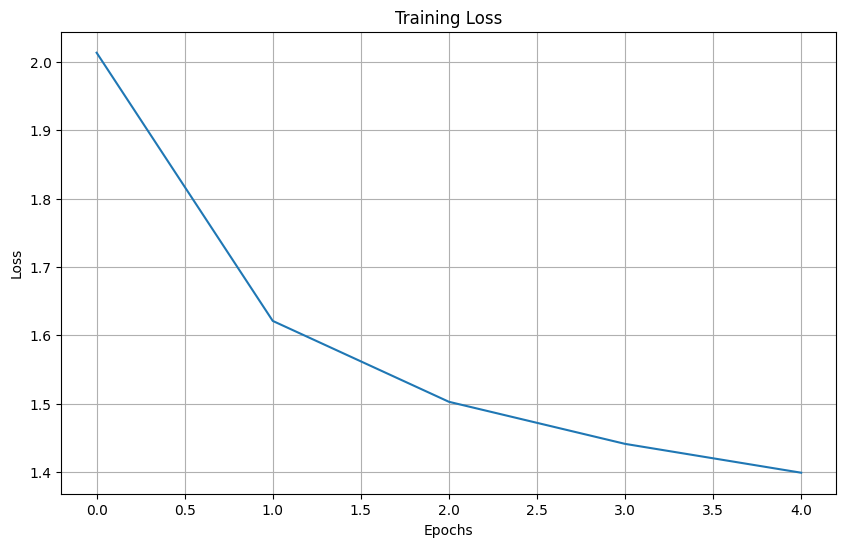

In [8]:
import matplotlib.pyplot as plt
# 绘制损失曲线
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# 预测

In [9]:
# 理解torch.multinomial函数的小例子
import torch
import torch.nn.functional as F

# 创建一个概率分布
probs = torch.tensor([0.1, 0.2, 0.3, 0.4])
print("概率分布:", probs)

# 从概率分布中采样一个元素
sample = torch.multinomial(probs, num_samples=1)
print("采样一个元素:", sample.item(), "对应概率:", probs[sample.item()].item())

概率分布: tensor([0.1000, 0.2000, 0.3000, 0.4000])
采样一个元素: 3 对应概率: 0.4000000059604645


原始logits值: tensor([1.0000, 2.0000, 5.0000, 3.0000, 0.5000])

temperature=0.5时的概率分布:
tensor([3.2848e-04, 2.4272e-03, 9.7919e-01, 1.7934e-02, 1.2084e-04])

temperature=1.0时的概率分布:
tensor([0.0151, 0.0410, 0.8234, 0.1114, 0.0091])

temperature=2.0时的概率分布:
tensor([0.0739, 0.1218, 0.5459, 0.2008, 0.0575])


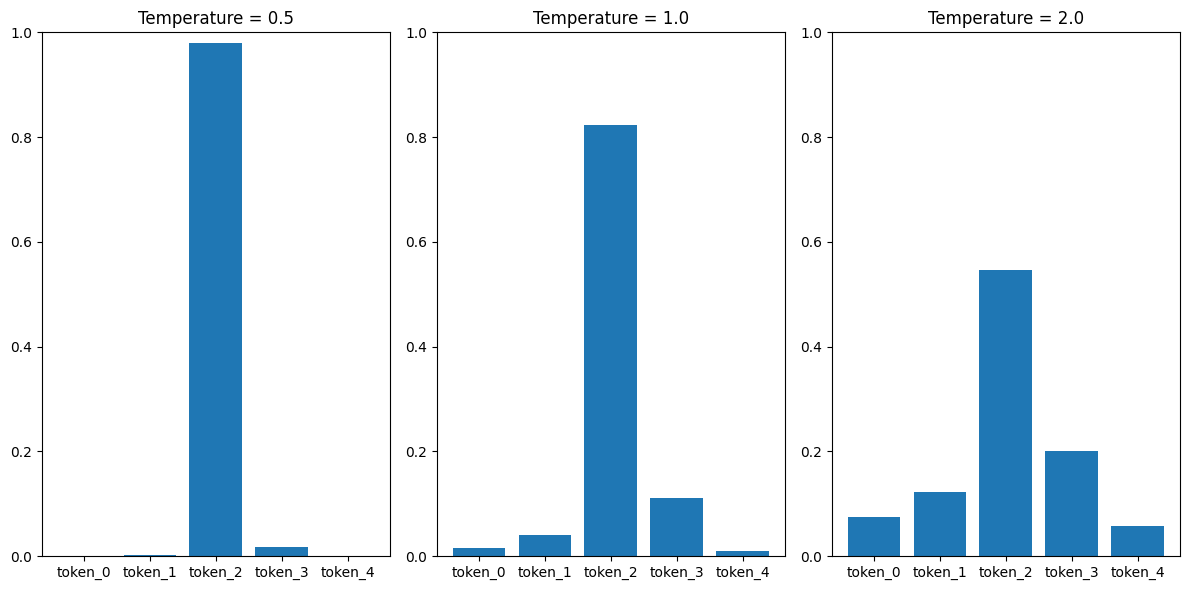


解释:
- 较低的temperature (如0.5) 使概率分布更加尖锐，最高概率的token被选中的可能性更大
- 标准temperature (1.0) 保持原始概率分布
- 较高的temperature (如2.0) 使概率分布更加平坦，增加了采样的随机性


In [ ]:
# 展示temperature参数对softmax输出的影响，并添加详细注释

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 创建一个模拟的logits输出（可以理解为模型最后一层输出的未归一化分数）
logits = torch.tensor([1.0, 2.0, 5.0, 3.0, 0.5])
print("原始logits值:", logits)

# 设定不同的temperature参数，用于观察softmax生成概率分布时的差异
temperatures = [0.5, 1.0, 2.0]  # 低温度（更确定），标准温度，高温度（结果更随机）

# 设置画布，准备可视化
plt.figure(figsize=(12, 6))

# 对每个temperature参数分别处理
for i, temp in enumerate(temperatures):
    # 对logits应用temperature缩放
    # temperature越小，分布越尖锐，temperature越大，分布越平坦
    scaled_logits = logits / temp  # 这里除以温度，实现分布的调节
    
    # 将缩放后的logits通过softmax归一化为概率分布
    probabilities = F.softmax(scaled_logits, dim=0)  # 概率和为1，每个元素代表该token被采样的概率
    
    # 打印不同temperature下的概率分布，便于直观观察
    print(f"\ntemperature={temp}时的概率分布:")
    print(probabilities)
    
    # 绘制每种temperature下的概率分布柱状图
    plt.subplot(1, len(temperatures), i+1)  # 多子图并列
    plt.bar(
        range(len(probabilities)), 
        probabilities.numpy(), 
        color='skyblue', 
        edgecolor='black'
    )
    # 设置标题，及y轴取值范围
    plt.title(f"Temperature = {temp}")
    plt.ylim(0, 1)
    # x轴显示各token标签
    plt.xticks(range(len(probabilities)), [f"token_{i}" for i in range(len(probabilities))])

# 使子图布局紧凑
plt.tight_layout()
plt.show()

# 文字解释
print("\n解释:")
print("- 较低的temperature (如0.5) 使概率分布更加尖锐，模型更倾向于选最高分（确定性更强）")
print("- 标准temperature (1.0) 保持原始概率分布")
print("- 较高的temperature (如2.0) 使概率分布更加平坦，采样结果更有随机性，能生成更多样化的内容")


# 温度是解码策略之一

In [11]:
# 生成文本函数
def generate_text(model, start_string, char2idx, idx2char, num_generate=1000, temperature=1.0):
    # 将模型设置为评估模式
    model.eval()
    
    # 将起始字符串转换为索引
    input_indices = [char2idx[char] for char in start_string]
    input_tensor = torch.tensor(input_indices, dtype=torch.long).unsqueeze(0).to(device) #unsqueeze(0) 在第0维上增加一个维度
    print(input_tensor.shape) #(1,5)
    # 存储生成的文本
    generated_text = start_string
    
    # 隐藏状态初始化为None，模型会自动初始化
    hidden = None
    
    # 生成指定数量的字符
    with torch.no_grad():
        for _ in range(num_generate):
            # 获取模型预测
            output, hidden = model(input_tensor,hidden)
            
            # 应用温度参数调整预测分布
            logits = output[:, -1, :] / temperature
            
            # 从调整后的分布中采样下一个字符
            probabilities = F.softmax(logits, dim=-1)
            predicted_id = torch.multinomial(probabilities, 1) #从概率分布中采样一个元素，概率越大，被选中的可能性越大
            
            # 将预测的字符添加到生成文本中
            generated_char = idx2char[predicted_id.item()]
            generated_text += generated_char #放入到生成序列
            
            # 更新输入张量为当前预测的字符
            input_tensor = predicted_id
    
    return generated_text

generate_text(model, 'hello',char2idx,idx2char)

torch.Size([1, 5])


"hellow.\n\nKING LEve I a killing, earl, doubl do your purped to come you.\n\nBENVOLIO:\nWhat, is there, small be thee?\nBut not thou,\nHaving such offecting on your condement:\nCome not, Call, the king see the people!\nAnd yet cold obediencl:\nO conceived\nAnd see cankine to hels will voice, forget me penatepous will not.\n\nBIONDELLO:\nFarewell thy hoffer rulest all do it?\nDitther had forth--dogelender, I think the eapscalt does. This long to about England, you shall be; and youth thy wila\nit betid,\nCome in stone attemply;\nOn Lancaster.\n\nSEBASTIAN:\nIntertand to speak, which woul at the best office at the others to cold to wook\nOf itselfs with us, consul what is conscience of her do cry Doly with resolbation, was for forcention of the lass of king?\nSuch liege: sweet Oxfrait. So sweep and forsurden'd innocender.\n\nKATHARINA:\nO son\nTo speak to find his son:\nWhere we peace more I will not, straight.\nAs besticious fool.\nHow was the palam.\n\nSecond Murderal,\nAnd wines over